In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
auth_features = pd.read_csv(
    "/content/drive/MyDrive/Cloud anomaly detection/processed/auth_features.csv"
)

In [4]:
print(auth_features.shape)

auth_features.head()

(50000, 15)


,failed_attempts,session_duration,password_age_days,privilege_level,threat_level,hour,day_of_week,month,is_failed_login,mfa_disabled,token_expired_flag,blocked_flag,suspicious_flag,is_weekend,late_night_login
0,1.583179,1.313836,0.149193,1.410506,1.574488,-1.667803,-0.496064,0.143591,1.002363,0.991754,1.00445,-0.575718,1.006783,-0.627044,1.742179
1,0.316306,1.500625,-0.343562,-0.711619,-0.004161,0.068711,-0.997393,1.590558,-0.997643,0.991754,1.00445,-0.575718,1.006783,-0.627044,-0.573994
2,-1.267284,0.025668,1.646411,-0.711619,1.574488,-1.088965,0.005264,-0.724589,-0.997643,0.991754,-0.99557,-0.575718,-0.993263,-0.627044,1.742179
3,0.316306,-1.706730,0.395571,-0.711619,-0.635621,-1.378384,0.506592,-1.303376,-0.997643,0.991754,-0.99557,-0.575718,1.006783,-0.627044,1.742179
4,-0.000412,0.222135,0.310286,-0.004244,1.258758,0.068711,1.007921,-1.303376,-0.997643,0.991754,1.00445,-0.575718,-0.993263,1.594784,-0.573994


In [5]:
auth_features.isnull().sum()

,0
failed_attempts,0
session_duration,0
password_age_days,0
privilege_level,0
threat_level,0
hour,0
day_of_week,0
month,0
is_failed_login,0
mfa_disabled,0


In [6]:
auth_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   failed_attempts     50000 non-null  float64
 1   session_duration    50000 non-null  float64
 2   password_age_days   50000 non-null  float64
 3   privilege_level     50000 non-null  float64
 4   threat_level        50000 non-null  float64
 5   hour                50000 non-null  float64
 6   day_of_week         50000 non-null  float64
 7   month               50000 non-null  float64
 8   is_failed_login     50000 non-null  float64
 9   mfa_disabled        50000 non-null  float64
 10  token_expired_flag  50000 non-null  float64
 11  blocked_flag        50000 non-null  float64
 12  suspicious_flag     50000 non-null  float64
 13  is_weekend          50000 non-null  float64
 14  late_night_login    50000 non-null  float64
dtypes: float64(15)
memory usage: 5.7 MB


In [7]:
auth_features.describe()

,failed_attempts,session_duration,password_age_days,privilege_level,threat_level,hour,day_of_week,month,is_failed_login,mfa_disabled,token_expired_flag,blocked_flag,suspicious_flag,is_weekend,late_night_login
count,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04
mean,1.362466e-16,1.071143e-16,-8.910206e-17,1.392664e-16,-8.832046e-17,-7.581491e-17,-1.698197e-17,-6.693313e-17,1.010392e-16,-8.810730e-18,1.820410e-16,1.037392e-16,-1.670486e-16,-1.259082e-16,-1.384137e-16
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.584002e+00,-1.722215e+00,-1.727066e+00,-1.418994e+00,-1.582811e+00,-1.667803e+00,-1.498721e+00,-1.592769e+00,-9.976428e-01,-1.008315e+00,-9.955698e-01,-5.757183e-01,-9.932627e-01,-6.270443e-01,-5.739939e-01
25%,-9.505661e-01,-8.656943e-01,-8.647450e-01,-7.116192e-01,-9.513508e-01,-7.995461e-01,-9.973929e-01,-7.245890e-01,-9.976428e-01,-1.008315e+00,-9.955698e-01,-5.757183e-01,-9.932627e-01,-6.270443e-01,-5.739939e-01
50%,-4.117336e-04,-3.366755e-03,-2.423597e-03,-4.244250e-03,-4.161319e-03,6.871097e-02,5.263948e-03,1.435912e-01,-9.976428e-01,9.917540e-01,-9.955698e-01,-5.757183e-01,-9.932627e-01,-6.270443e-01,-5.739939e-01
75%,9.497427e-01,8.667033e-01,8.598978e-01,7.031307e-01,9.430282e-01,9.369681e-01,1.007921e+00,1.011771e+00,1.002363e+00,9.917540e-01,1.004450e+00,-5.757183e-01,1.006783e+00,1.594784e+00,-5.739939e-01
max,1.583179e+00,1.732902e+00,1.731695e+00,1.410506e+00,1.574488e+00,1.660516e+00,1.509249e+00,1.590558e+00,1.002363e+00,9.917540e-01,1.004450e+00,1.736961e+00,1.006783e+00,1.594784e+00,1.742179e+00


In [8]:
from sklearn.ensemble import IsolationForest

In [9]:
iso_auth = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

In [10]:
auth_features['if_prediction'] = iso_auth.fit_predict(
    auth_features
)

In [11]:
auth_features['if_prediction'].value_counts()

,count
if_prediction,
1,47500
-1,2500


In [12]:
auth_features['if_prediction'].value_counts(
    normalize=True
)

,proportion
if_prediction,
1,0.95
-1,0.05


In [13]:
auth_features['if_score'] = iso_auth.decision_function(
    auth_features.drop(columns=['if_prediction'])
)

In [14]:
auth_features[['if_prediction',
               'if_score']].head()

,if_prediction,if_score
0,1,0.007352
1,1,0.083144
2,1,0.032198
3,1,0.044431
4,1,0.069308


In [15]:
from sklearn.neighbors import LocalOutlierFactor

In [16]:
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.05,
    novelty=True
)

In [17]:
lof_features = auth_features.drop(
    columns=[
        'if_prediction',
        'if_score'
    ]
)

lof.fit(lof_features)

auth_features['lof_prediction'] = lof.predict(
    lof_features
)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


In [18]:
import os
import joblib

model_path = "/content/drive/MyDrive/Cloud anomaly detection/models/auth"

os.makedirs(model_path, exist_ok=True)

joblib.dump(
    iso_auth,
    f"{model_path}/auth_if.pkl"
)

joblib.dump(
    lof,
    f"{model_path}/auth_lof.pkl"
)

print("Authentication models saved successfully")

Authentication models saved successfully


In [19]:
loaded_if = joblib.load(
    f"{model_path}/auth_if.pkl"
)

loaded_lof = joblib.load(
    f"{model_path}/auth_lof.pkl"
)

print(type(loaded_if))
print(type(loaded_lof))

print("Model verification successful")

<class 'sklearn.ensemble._iforest.IsolationForest'>
<class 'sklearn.neighbors._lof.LocalOutlierFactor'>
Model verification successful


In [20]:
auth_features['lof_prediction'].value_counts()

,count
lof_prediction,
1,47902
-1,2098


In [26]:
auth_features['lof_score'] = lof.score_samples(
    lof_features
)

print("LOF scores generated successfully")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


LOF scores generated successfully


In [27]:
auth_features[['lof_prediction',
               'lof_score']].head()

,lof_prediction,lof_score
0,1,-1.040140
1,1,-1.009870
2,1,-1.009817
3,1,-1.037816
4,1,-0.971834


In [28]:
auth_features['ensemble_anomaly'] = np.where(
    (auth_features['if_prediction'] == -1) |
    (auth_features['lof_prediction'] == -1),
    1,
    0
)

In [29]:
auth_features['ensemble_anomaly'].value_counts()

,count
ensemble_anomaly,
0,45779
1,4221


In [30]:
auth_features['ensemble_anomaly'].value_counts(
    normalize=True
)

,proportion
ensemble_anomaly,
0,0.91558
1,0.08442


In [31]:
auth_features['severity_score'] = (
    -auth_features['if_score']
)

In [32]:
auth_features['severity_score'].describe()

,severity_score
count,50000.000000
mean,-0.044811
std,0.026487
min,-0.118491
25%,-0.064279
50%,-0.045519
75%,-0.026261
max,0.051635


In [33]:
top_anomalies = auth_features.sort_values(
    'severity_score',
    ascending=False
)

top_anomalies.head(20)

,failed_attempts,session_duration,password_age_days,privilege_level,threat_level,hour,day_of_week,month,is_failed_login,mfa_disabled,...,blocked_flag,suspicious_flag,is_weekend,late_night_login,if_prediction,if_score,lof_prediction,lof_score,ensemble_anomaly,severity_score
21225,-1.584002,-0.860855,1.589554,1.410506,0.627298,-1.667803,1.509249,-1.592769,1.002363,0.991754,...,1.736961,-0.993263,1.594784,1.742179,-1,-0.051635,1,-1.045919,1,0.051635
39689,-1.584002,0.265687,0.442951,1.410506,-1.267081,-1.667803,1.509249,-1.592769,1.002363,-1.008315,...,1.736961,1.006783,1.594784,1.742179,-1,-0.046822,1,-1.037343,1,0.046822
36531,-0.950566,1.202537,-1.281692,-1.418994,-1.582811,-0.944256,1.509249,-1.592769,1.002363,-1.008315,...,1.736961,1.006783,1.594784,1.742179,-1,-0.045291,1,-1.058317,1,0.045291
49474,-1.267284,-1.196689,1.400033,1.410506,-1.267081,-1.088965,1.509249,-1.592769,1.002363,0.991754,...,1.736961,1.006783,1.594784,1.742179,-1,-0.042701,-1,-1.100838,1,0.042701
3619,1.583179,-1.624465,-1.556497,-0.004244,-1.582811,-1.378384,1.509249,-1.013982,1.002363,-1.008315,...,1.736961,1.006783,1.594784,1.742179,-1,-0.041786,1,-1.056506,1,0.041786
43239,1.266461,-1.307020,-1.054266,-1.418994,-1.267081,-1.667803,1.509249,-1.013982,1.002363,-1.008315,...,1.736961,-0.993263,1.594784,1.742179,-1,-0.041402,1,-1.034623,1,0.041402
926,-1.584002,-1.606077,-0.552035,0.703131,-1.267081,-1.667803,1.509249,-1.013982,1.002363,-1.008315,...,1.736961,-0.993263,1.594784,1.742179,-1,-0.041327,1,-1.052615,1,0.041327
30509,-0.950566,-1.452193,-1.338548,-0.711619,0.627298,-1.667803,1.509249,-1.592769,1.002363,-1.008315,...,1.736961,-0.993263,1.594784,1.742179,-1,-0.040634,1,-1.017819,1,0.040634
22917,0.949743,-0.695358,-1.717590,-1.418994,-0.635621,-1.378384,1.509249,1.590558,1.002363,0.991754,...,1.736961,1.006783,1.594784,1.742179,-1,-0.039740,1,-1.055913,1,0.039740
47451,1.266461,0.075027,-1.603878,-1.418994,-1.582811,-1.088965,1.509249,-1.592769,1.002363,-1.008315,...,1.736961,1.006783,1.594784,1.742179,-1,-0.039157,1,-1.047419,1,0.039157


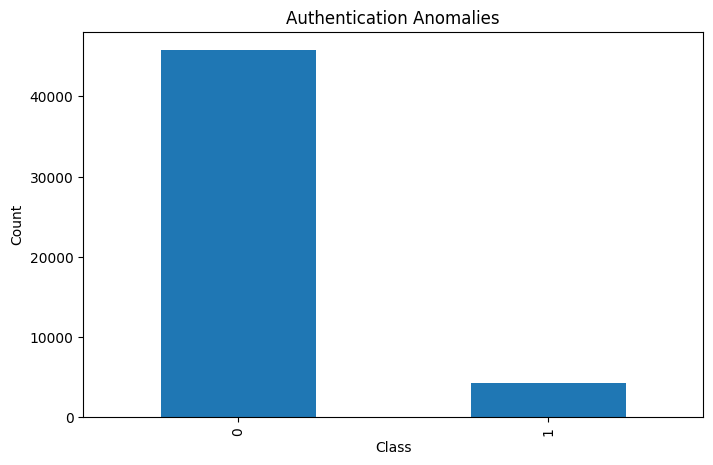

In [34]:
plt.figure(figsize=(8,5))

auth_features['ensemble_anomaly'].value_counts().plot(
    kind='bar'
)

plt.title("Authentication Anomalies")
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

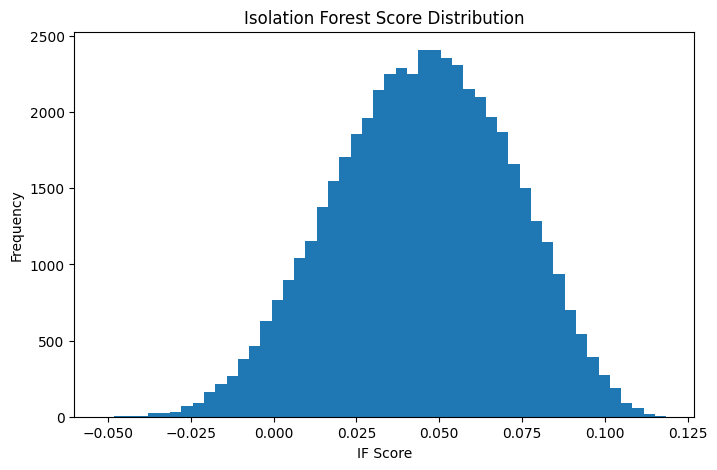

In [35]:
plt.figure(figsize=(8,5))

plt.hist(
    auth_features['if_score'],
    bins=50
)

plt.title("Isolation Forest Score Distribution")
plt.xlabel("IF Score")
plt.ylabel("Frequency")

plt.show()

In [36]:
save_path = "/content/drive/MyDrive/Cloud anomaly detection/results/auth_anomalies.csv"

auth_features.to_csv(
    save_path,
    index=False
)

print("Authentication anomalies saved")

Authentication anomalies saved


In [37]:
auth_features['if_prediction'].value_counts()

,count
if_prediction,
1,47500
-1,2500


In [38]:
auth_features['ensemble_anomaly'].value_counts()

,count
ensemble_anomaly,
0,45779
1,4221


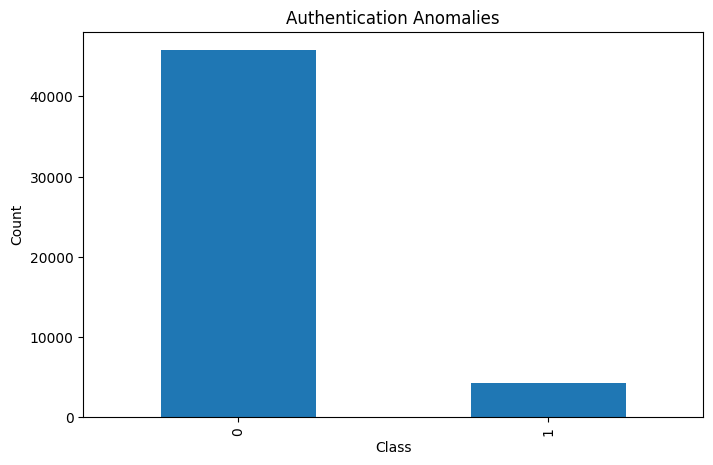

In [39]:
import os

auth_result_path = "/content/drive/MyDrive/Cloud anomaly detection/results/auth"
os.makedirs(auth_result_path, exist_ok=True)

plt.figure(figsize=(8,5))

auth_features['ensemble_anomaly'].value_counts().plot(kind='bar')

plt.title("Authentication Anomalies")
plt.xlabel("Class")
plt.ylabel("Count")

plt.savefig(
    f"{auth_result_path}/auth_anomaly_count.png",
    bbox_inches="tight"
)

plt.show()

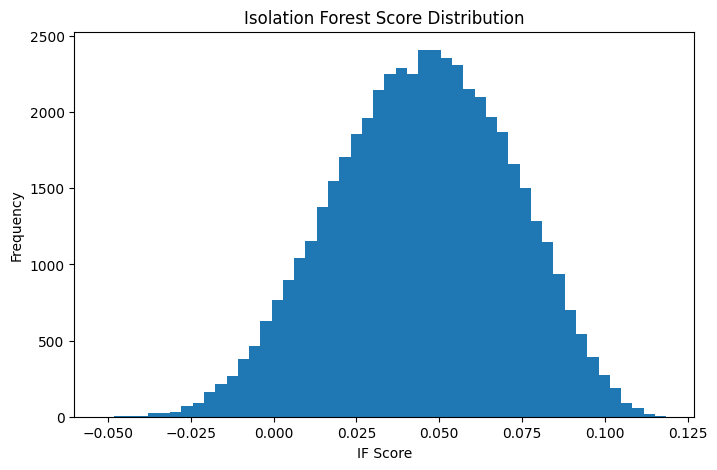

In [40]:
plt.figure(figsize=(8,5))

plt.hist(
    auth_features['if_score'],
    bins=50
)

plt.title("Isolation Forest Score Distribution")
plt.xlabel("IF Score")
plt.ylabel("Frequency")

plt.savefig(
    f"{auth_result_path}/auth_if_score_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [41]:
auth_features.to_csv(
    f"{auth_result_path}/auth_anomalies.csv",
    index=False
)

print("CSV saved")

CSV saved


In [42]:
total_records = len(auth_features)

if_anomalies = (
    auth_features['if_prediction'] == -1
).sum()

lof_anomalies = (
    auth_features['lof_prediction'] == -1
).sum()

ensemble_anomalies = (
    auth_features['ensemble_anomaly'] == 1
).sum()

summary = f"""
AUTHENTICATION ANOMALY DETECTION RESULTS
========================================

Total Records: {total_records}

Isolation Forest:
Anomalies Detected: {if_anomalies}
Percentage: {(if_anomalies/total_records)*100:.2f}%

Local Outlier Factor:
Anomalies Detected: {lof_anomalies}
Percentage: {(lof_anomalies/total_records)*100:.2f}%

Ensemble Detection:
Anomalies Detected: {ensemble_anomalies}
Percentage: {(ensemble_anomalies/total_records)*100:.2f}%
"""

with open(
    f"{auth_result_path}/auth_summary.txt",
    "w"
) as f:
    f.write(summary)

print(summary)


AUTHENTICATION ANOMALY DETECTION RESULTS

Total Records: 50000

Isolation Forest:
Anomalies Detected: 2500
Percentage: 5.00%

Local Outlier Factor:
Anomalies Detected: 2098
Percentage: 4.20%

Ensemble Detection:
Anomalies Detected: 4221
Percentage: 8.44%



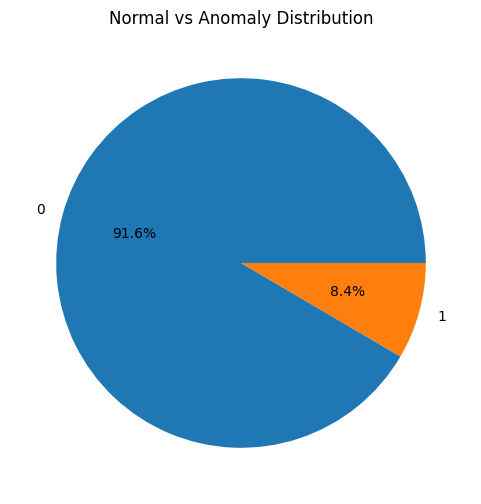

In [43]:
plt.figure(figsize=(6,6))

auth_features['ensemble_anomaly'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title("Normal vs Anomaly Distribution")

plt.ylabel("")

plt.savefig(
    f"{auth_result_path}/auth_anomaly_pie.png",
    bbox_inches="tight"
)

plt.show()

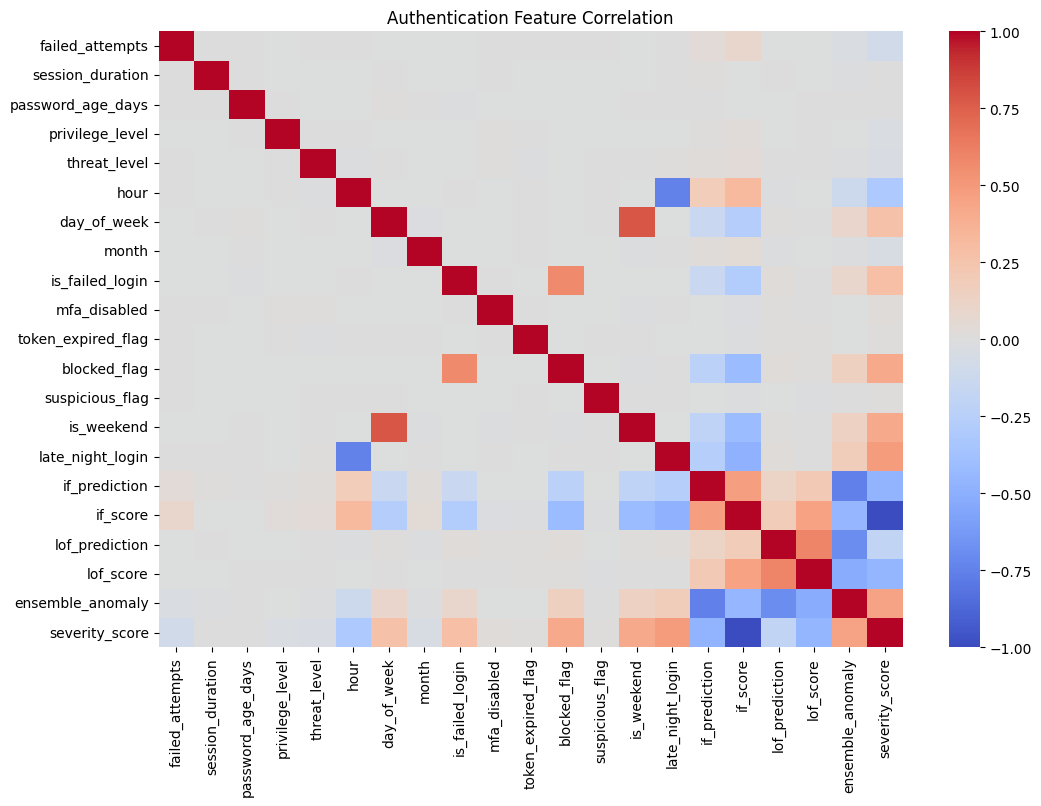

In [44]:
import seaborn as sns

plt.figure(figsize=(12,8))

sns.heatmap(
    auth_features.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title("Authentication Feature Correlation")

plt.savefig(
    f"{auth_result_path}/auth_correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

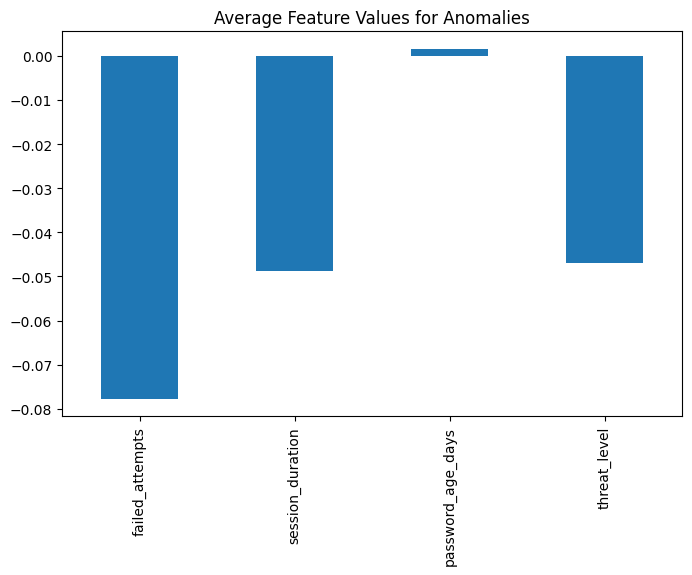

In [45]:
anomaly_data = auth_features[
    auth_features['ensemble_anomaly'] == 1
]

feature_means = anomaly_data[
    [
        'failed_attempts',
        'session_duration',
        'password_age_days',
        'threat_level'
    ]
].mean()

plt.figure(figsize=(8,5))

feature_means.plot(kind='bar')

plt.title("Average Feature Values for Anomalies")

plt.savefig(
    f"{auth_result_path}/auth_anomaly_feature_means.png",
    bbox_inches="tight"
)

plt.show()

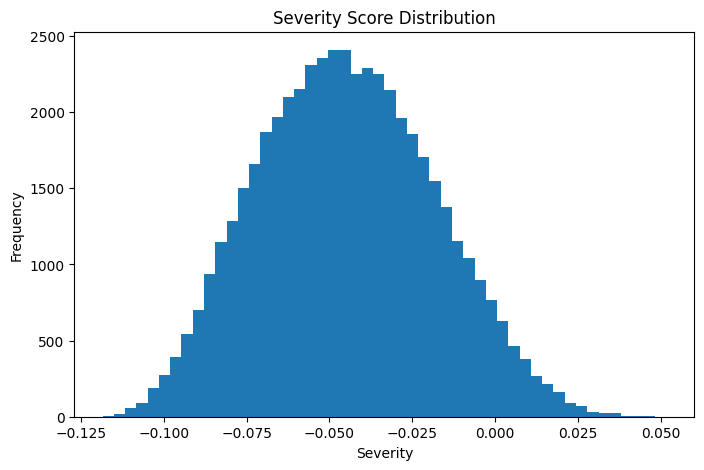

In [46]:
plt.figure(figsize=(8,5))

plt.hist(
    auth_features['severity_score'],
    bins=50
)

plt.title("Severity Score Distribution")

plt.xlabel("Severity")

plt.ylabel("Frequency")

plt.savefig(
    f"{auth_result_path}/auth_severity_distribution.png",
    bbox_inches="tight"
)

plt.show()

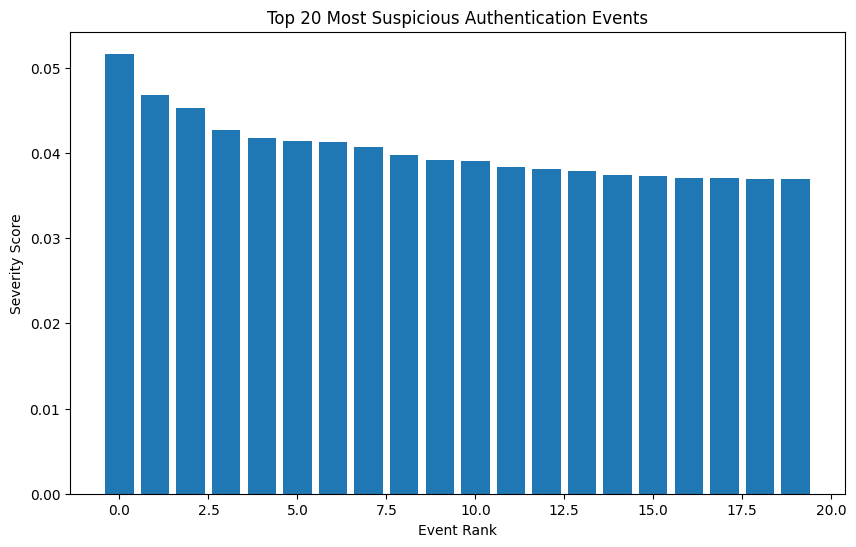

In [47]:
top20 = auth_features.nlargest(
    20,
    'severity_score'
)

plt.figure(figsize=(10,6))

plt.bar(
    range(20),
    top20['severity_score']
)

plt.title("Top 20 Most Suspicious Authentication Events")

plt.xlabel("Event Rank")

plt.ylabel("Severity Score")

plt.savefig(
    f"{auth_result_path}/auth_top20_anomalies.png",
    bbox_inches="tight"
)

plt.show()

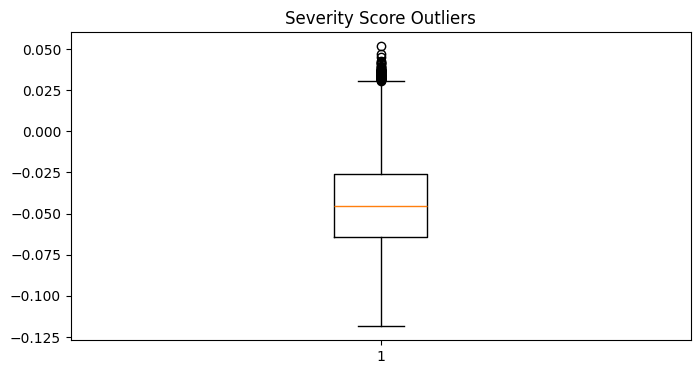

In [48]:
plt.figure(figsize=(8,4))

plt.boxplot(
    auth_features['severity_score']
)

plt.title("Severity Score Outliers")

plt.savefig(
    f"{auth_result_path}/auth_severity_boxplot.png",
    bbox_inches="tight"
)

plt.show()